# Error Analysis & Comparison Report

Ноутбук агрегирует результаты:
- `metrics/dense_hybrid_metrics.csv`
- `metrics/dense_hybrid_error_rows.csv`
- `metrics/dense_hybrid_error_summary.csv`
- `bm25_metrics_question.csv`
- `bm25_per_query_question.csv`
- `bm25_errors_question.csv`
- `bm25_error_summary_question.csv`

И строит:
1. таблицы сравнения моделей;
2. анализ ошибок BM25 и dense/hybrid;
3. финальный текстовый отчёт в стиле заключения.


In [6]:
!pip install pandas numpy matplotlib

  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.3 MB/s  0:00:01 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 6.8 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE_DIR = Path(os.environ.get("EE_RAG_BASE_DIR", os.getcwd()))
METRICS_DIR = BASE_DIR / "metrics"

paths = {
    "dense_metrics": METRICS_DIR / "dense_hybrid_metrics.csv",
    "dense_errors": METRICS_DIR / "dense_hybrid_error_rows.csv",
    "dense_error_summary": METRICS_DIR / "dense_hybrid_error_summary.csv",
    "bm25_metrics": BASE_DIR / "bm25_metrics_question.csv",
    "bm25_per_query": BASE_DIR / "bm25_per_query_question.csv",
    "bm25_errors": BASE_DIR / "bm25_errors_question.csv",
    "bm25_error_summary": BASE_DIR / "bm25_error_summary_question.csv",
}



In [9]:
def load_csv(path: Path, required=True):
    if path.exists():
        return pd.read_csv(path)
    if required:
        raise FileNotFoundError(f"Missing required CSV: {path}")
    return pd.DataFrame()

dense_metrics = load_csv(paths["dense_metrics"])
dense_errors = load_csv(paths["dense_errors"])
dense_error_summary = load_csv(paths["dense_error_summary"], required=False)
bm25_metrics = load_csv(paths["bm25_metrics"])
bm25_per_query = load_csv(paths["bm25_per_query"], required=False)
bm25_errors = load_csv(paths["bm25_errors"], required=False)
bm25_error_summary = load_csv(paths["bm25_error_summary"], required=False)

print("dense_metrics:", dense_metrics.shape)
print("dense_errors:", dense_errors.shape)
print("bm25_metrics:", bm25_metrics.shape)


dense_metrics: (5, 8)
dense_errors: (2749, 18)
bm25_metrics: (8, 7)


## 1) Сравнение метрик (Recall / MRR / nDCG)


In [10]:
for col in ["Recall", "MRR", "nDCG", "k", "Hits", "Total"]:
    if col in dense_metrics.columns:
        dense_metrics[col] = pd.to_numeric(dense_metrics[col], errors="coerce")

for col in ["recall", "mrr", "ndcg", "k", "count"]:
    if col in bm25_metrics.columns:
        bm25_metrics[col] = pd.to_numeric(bm25_metrics[col], errors="coerce")

# Dense/HYBRID (берем как есть)
dense_cmp = dense_metrics.copy()
dense_cmp["Source"] = "Dense/Hybrid"
dense_cmp = dense_cmp.rename(columns={"Mode": "Group", "Model": "Model", "Recall": "Recall", "MRR": "MRR", "nDCG": "nDCG", "k": "k"})
dense_cmp = dense_cmp[["Source", "Group", "Model", "k", "Recall", "MRR", "nDCG", "Hits", "Total"]]

# BM25 (берем overall/text/image/hybrid на k=5 и k=10)
bm25_cmp = bm25_metrics.copy()
bm25_cmp["Source"] = "BM25"
bm25_cmp["Group"] = bm25_cmp["group"]
bm25_cmp["Model"] = "BM25"
bm25_cmp["Hits"] = np.nan
bm25_cmp["Total"] = bm25_cmp["count"]
bm25_cmp = bm25_cmp.rename(columns={"recall": "Recall", "mrr": "MRR", "ndcg": "nDCG"})
bm25_cmp = bm25_cmp[["Source", "Group", "Model", "k", "Recall", "MRR", "nDCG", "Hits", "Total"]]

comparison = pd.concat([dense_cmp, bm25_cmp], ignore_index=True)
comparison = comparison.sort_values(["k", "Recall"], ascending=[True, False])

# Удобный формат процентов
pretty = comparison.copy()
for c in ["Recall", "MRR", "nDCG"]:
    pretty[c] = (pretty[c] * 100).round(2)

print("Сводная таблица (проценты):")
display(pretty)

out_path = METRICS_DIR / "comparison_metrics_table.csv"
comparison.to_csv(out_path, index=False, encoding="utf-8")
print(f"Saved: {out_path}")


Сводная таблица (проценты):


,Source,Group,Model,k,Recall,MRR,nDCG,Hits,Total
9,BM25,text,BM25,5,71.82,58.63,61.91,NaN,369
7,BM25,hybrid,BM25,5,70.26,62.85,64.71,NaN,195
2,Dense/Hybrid,RAG (Question),Text Only (BGE),5,62.12,53.96,48.29,433.0,697
5,BM25,overall,BM25,5,57.76,48.69,50.95,NaN,696
0,Dense/Hybrid,Vision (Semantic),SigLIP,5,3.96,2.36,1.69,13.0,328
1,Dense/Hybrid,Vision (Semantic),OpenAI CLIP,5,0.00,0.00,0.00,0.0,328
11,BM25,image,BM25,5,0.00,0.00,0.00,NaN,132
10,BM25,text,BM25,10,78.86,59.60,64.22,NaN,369
8,BM25,hybrid,BM25,10,73.33,63.26,65.70,NaN,195
4,Dense/Hybrid,RAG (Question),BGE + OpenAI CLIP,10,66.43,54.54,49.49,463.0,697


Saved: /Users/sergey/Documents/Computer Science/Electro_rag_article/metrics/comparison_metrics_table.csv


,Source,Group,Model,Recall,MRR,nDCG
9,BM25,text,BM25,0.718157,0.586269,0.619103
7,BM25,hybrid,BM25,0.702564,0.628547,0.647132
2,Dense/Hybrid,RAG (Question),Text Only (BGE),0.621234,0.539550,0.482907
5,BM25,overall,BM25,0.577586,0.486925,0.509540
0,Dense/Hybrid,Vision (Semantic),SigLIP,0.039634,0.023628,0.016925
1,Dense/Hybrid,Vision (Semantic),OpenAI CLIP,0.000000,0.000000,0.000000
11,BM25,image,BM25,0.000000,0.000000,0.000000


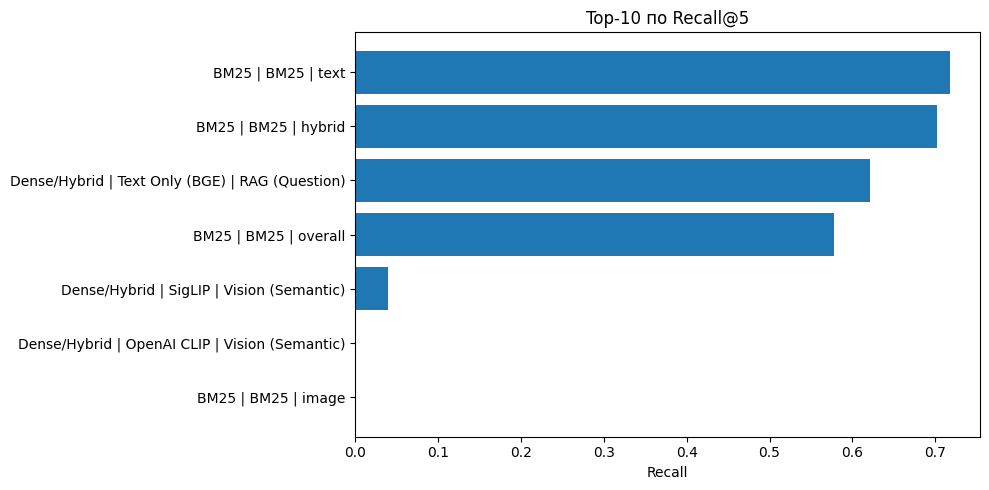

In [11]:
# Топ моделей по Recall@5
top_k = 5
top5 = comparison[comparison["k"] == top_k].sort_values("Recall", ascending=False).head(10)

display(top5[["Source", "Group", "Model", "Recall", "MRR", "nDCG"]])

plt.figure(figsize=(10, 5))
labels = top5["Source"] + " | " + top5["Model"] + " | " + top5["Group"].astype(str)
plt.barh(labels[::-1], top5["Recall"][::-1])
plt.title("Top-10 по Recall@5")
plt.xlabel("Recall")
plt.tight_layout()
plt.show()


## 2) Аналитика ошибок BM25


In [12]:
if not bm25_errors.empty:
    # Распределение ошибок по типу и bucket
    if "type" in bm25_errors.columns:
        type_miss = bm25_errors["type"].value_counts().rename_axis("type").reset_index(name="miss_count")
        display(type_miss)

    if "error_bucket" in bm25_errors.columns:
        bucket_miss = bm25_errors["error_bucket"].value_counts().rename_axis("error_bucket").reset_index(name="miss_count")
        display(bucket_miss)

    # Топ сложных вопросов по длине
    if "query_tokens" in bm25_errors.columns:
        long_fails = bm25_errors.sort_values("query_tokens", ascending=False).head(20)
        display(long_fails[[c for c in ["query", "type", "query_tokens", "error_bucket", "pred_top10"] if c in long_fails.columns]])

    out_path = METRICS_DIR / "bm25_error_analysis_table.csv"
    bm25_errors.to_csv(out_path, index=False, encoding="utf-8")
    print(f"Saved: {out_path}")
else:
    print("bm25_errors_question.csv пустой или отсутствует")


,type,miss_count
0,image,132
1,text,78
2,hybrid,52


,error_bucket,miss_count
0,lexical_mismatch,262


,query,type,query_tokens,error_bucket,pred_top10
198,Какие из следующих утверждений верны для гармо...,hybrid,93,lexical_mismatch,L06_p37|L13_p9|L14_p41|L05_p77|L17_p35|L31_p8|...
18,Какие характеристики имеют векторы системы пря...,hybrid,47,lexical_mismatch,L23_p59|L31_p61|L31_p75|L04_p61|L16_p11|L23_p5...
98,Используя формулу i = 200(e^-5t - e^-10t)A и у...,hybrid,43,lexical_mismatch,L28_p30|L03_p23|L26_p35|L25_p88|L29_p6|L29_p1|...
92,"Как изменится значение тока I(p) в цепи, если ...",hybrid,42,lexical_mismatch,L26_p14|L25_p27|L24_p14|L26_p78|L01_p60|L25_p1...
141,Какой метод используется для расчета нелинейно...,hybrid,38,lexical_mismatch,L35_p36|L36_p60|L38_p18|L39_p73|L33_p48|L36_p5...
28,"На рисунке 5, а представлена формула для тока ...",hybrid,33,lexical_mismatch,L03_p23|L06_p6|L21_p27|L31_p67|L21_p14|L22_p63...
112,Какое комплексное сопротивление катушки индукт...,hybrid,33,lexical_mismatch,L03_p6|L23_p64|L10_p7|L22_p63|L05_p80|L05_p82|...
211,На рисунке 1 изображена электрическая цепь с и...,hybrid,31,lexical_mismatch,L23_p88|L37_p31|L10_p14|L10_p11|L05_p4|L23_p1|...
181,Какие зависимости между сопротивлениями и напр...,hybrid,30,lexical_mismatch,L05_p59|L08_p19|L05_p56|L05_p55|L40_p6|L05_p80...
165,"Как изменится момент в цепи после коммутации, ...",hybrid,29,lexical_mismatch,L07_p63|L13_p20|L01_p61|L23_p88|L39_p104|L09_p...


Saved: /Users/sergey/Documents/Computer Science/Electro_rag_article/metrics/bm25_error_analysis_table.csv


## 3) Аналитика ошибок Dense/Hybrid


In [13]:
if not dense_errors.empty:
    de = dense_errors.copy()
    for c in ["hit", "recall", "mrr", "ndcg", "k"]:
        if c in de.columns:
            de[c] = pd.to_numeric(de[c], errors="coerce")

    valid = de[de["method"] != "runtime_error"].copy() if "method" in de.columns else de.copy()

    # Miss-rate по экспериментам
    exp_stats = (
        valid.groupby("experiment", dropna=False)
        .agg(total=("hit", "size"), hits=("hit", "sum"))
        .reset_index()
    )
    exp_stats["miss_rate"] = 1.0 - (exp_stats["hits"] / exp_stats["total"])
    exp_stats = exp_stats.sort_values("miss_rate", ascending=False)
    display(exp_stats)

    # Miss-rate по типам
    if "item_type" in valid.columns:
        type_stats = (
            valid.groupby(["experiment", "item_type"], dropna=False)
            .agg(total=("hit", "size"), hits=("hit", "sum"))
            .reset_index()
        )
        type_stats["miss_rate"] = 1.0 - (type_stats["hits"] / type_stats["total"])
        type_stats = type_stats.sort_values(["experiment", "miss_rate"], ascending=[True, False])
        display(type_stats)

    # Часто повторяющиеся проблемные вопросы
    if "query" in valid.columns:
        hard_queries = (
            valid[valid["hit"] == 0]
            .groupby(["query", "experiment"], dropna=False)
            .size()
            .reset_index(name="miss_count")
            .sort_values("miss_count", ascending=False)
            .head(30)
        )
        display(hard_queries)

    out1 = METRICS_DIR / "dense_error_experiment_stats.csv"
    exp_stats.to_csv(out1, index=False, encoding="utf-8")
    print(f"Saved: {out1}")

    if "item_type" in valid.columns:
        out2 = METRICS_DIR / "dense_error_type_stats.csv"
        type_stats.to_csv(out2, index=False, encoding="utf-8")
        print(f"Saved: {out2}")

    if "query" in valid.columns:
        out3 = METRICS_DIR / "dense_hard_queries.csv"
        hard_queries.to_csv(out3, index=False, encoding="utf-8")
        print(f"Saved: {out3}")

else:
    print("dense_hybrid_error_rows.csv пустой или отсутствует")


,experiment,total,hits,miss_rate
3,Vis: CLIP (Answer),328,0,1.000000
4,Vis: SigLIP (Answer),328,13,0.960366
2,Text Only (BGE),697,433,0.378766
1,Hybrid: BGE + SigLIP,697,436,0.374462
0,Hybrid: BGE + CLIP,697,463,0.335725


,experiment,item_type,total,hits,miss_rate
1,Hybrid: BGE + CLIP,image,133,0,1.000000
0,Hybrid: BGE + CLIP,hybrid,195,159,0.184615
2,Hybrid: BGE + CLIP,text,369,304,0.176152
4,Hybrid: BGE + SigLIP,image,133,0,1.000000
5,Hybrid: BGE + SigLIP,text,369,285,0.227642
3,Hybrid: BGE + SigLIP,hybrid,195,151,0.225641
7,Text Only (BGE),image,133,0,1.000000
6,Text Only (BGE),hybrid,195,148,0.241026
8,Text Only (BGE),text,369,285,0.227642
9,Vis: CLIP (Answer),hybrid,195,0,1.000000


,query,experiment,miss_count
400,Какие элементы соединены в этой схеме?,Hybrid: BGE + CLIP,45
401,Какие элементы соединены в этой схеме?,Hybrid: BGE + SigLIP,45
402,Какие элементы соединены в этой схеме?,Text Only (BGE),45
411,Какие элементы соединены между собой в этой сх...,Text Only (BGE),26
409,Какие элементы соединены между собой в этой сх...,Hybrid: BGE + CLIP,26
410,Какие элементы соединены между собой в этой сх...,Hybrid: BGE + SigLIP,26
414,Какие элементы соединены между собой на этой с...,Text Only (BGE),14
413,Какие элементы соединены между собой на этой с...,Hybrid: BGE + SigLIP,14
412,Какие элементы соединены между собой на этой с...,Hybrid: BGE + CLIP,14
362,Какие элементы связаны между собой в этой схеме?,Hybrid: BGE + SigLIP,7


Saved: /Users/sergey/Documents/Computer Science/Electro_rag_article/metrics/dense_error_experiment_stats.csv
Saved: /Users/sergey/Documents/Computer Science/Electro_rag_article/metrics/dense_error_type_stats.csv
Saved: /Users/sergey/Documents/Computer Science/Electro_rag_article/metrics/dense_hard_queries.csv
